In [99]:
import pandas as pd
from utils import *
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Cargamos todo

#### Pluvio SAIH

In [19]:
path = "Ramblas/"
# Diccionario para almacenar los dataframes
dataframes = {}

for folder in os.listdir(path):
    ruta_carpeta = os.path.join(path, folder)
    # Verificar que sea una carpeta
    if os.path.isdir(ruta_carpeta):
        # Buscar archivos que terminen en "-Pluviometro.parquet" en la carpeta
        for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith('-Pluviometro.parquet'):
                ruta_archivo = os.path.join(ruta_carpeta, archivo)
                df = pd.read_parquet(ruta_archivo)
                # Crear el nombre del dataframe usando el nombre de la carpeta
                nombre_df = f"{folder[6:]}_pluviometro"
                # Almacenar el dataframe en el diccionario
                dataframes[nombre_df] = df

pluvios_to_keep = ["Desemboc Rbla Albujon_pluviometro", "La Puebla_pluviometro", "Pozo Estrecho_pluviometro", "Rbla Albujon_pluviometro", "El Estrecho_pluviometro", "Fuente Alamo_pluviometro", "Los Cegarras_pluviometro"]
dataframes = {key: df for key, df in dataframes.items() if key in pluvios_to_keep}

# Dataframe vacío
combined_df = pd.DataFrame()

# Iterar sobre cada dataframe filtrado
for location, df in dataframes.items():
    df = df.set_index("Date")
    df = df.rename(columns={"Pluviometro": location})

    if combined_df.empty:
        combined_df = df
    else:
        combined_df = combined_df.join(df, how="outer")

combined_df = combined_df.reset_index()
# Convertir la columna 'Date' al formato datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
# Ponemos la fecha como índice
combined_df = combined_df.set_index('Date')
# Reemplazamos las '-' con NaN
combined_df.replace('-', np.nan, inplace=True)
# Reemplazamos NaN por 0's
combined_df.fillna(0, inplace=True)
# Ponemos como float los valores de los pluvios
combined_df = combined_df.astype({col: 'float' for col in combined_df.columns})
# Agrupamos los datos por día, sumando la precipitación acumulada
df_pluvio = combined_df.resample('D').sum()
# Definimos una columna que sea la suma de todos los pluvios
df_pluvio['Total'] = df_pluvio.loc[:, df_pluvio.columns].sum(axis=1)
df_pluvio = df_pluvio.reset_index()

#### Caudal SAIH

In [20]:
path = "Ramblas/"
dataframes = {}

for folder in os.listdir(path):
    ruta_carpeta = os.path.join(path, folder)
    # Verificar que sea una carpeta
    if os.path.isdir(ruta_carpeta):
        # Buscar archivos que terminen en "-Pluviometro.parquet" en la carpeta
        for archivo in os.listdir(ruta_carpeta):
            if archivo.endswith('-Caudal.parquet'):
                ruta_archivo = os.path.join(ruta_carpeta, archivo)
                df = pd.read_parquet(ruta_archivo)
                # Crear el nombre del dataframe usando el nombre de la carpeta
                nombre_df = f"{folder[6:]}_caudal"
                # Almacenar el dataframe en el diccionario
                dataframes[nombre_df] = df

caudal_to_keep = ["Desemboc Rbla Albujon_caudal"]
dataframes = {key: df for key, df in dataframes.items() if key in caudal_to_keep}

# Dataframe vacío
combined_df = pd.DataFrame()

# Iterar sobre cada dataframe filtrado
for location, df in dataframes.items():
    df = df.set_index("Date")
    df = df.rename(columns={"Caudal": location})

    if combined_df.empty:
        combined_df = df
    else:
        combined_df = combined_df.join(df, how="outer")

combined_df = combined_df.reset_index()
# Convertir la columna 'Date' al formato datetime
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
# Ponemos la fecha como índice
combined_df = combined_df.set_index('Date')
# Reemplazamos las '-' con NaN
#combined_df.replace('-', np.nan, inplace=True)
combined_df.replace(['-', 'null', 'NULL', 'None', ''], np.nan, inplace=True)
# Reemplazamos NaN por 0's
combined_df.fillna(0, inplace=True)
# Ponemos como float los valores de los pluvios
combined_df = combined_df.astype({col: 'float' for col in combined_df.columns})
# Agrupamos los datos por día, sumando la precipitación acumulada
df_caudal = combined_df.resample('D').mean()*1000 # *1000 Para estar en l/s
# Definimos una columna que sea la suma de todos los pluvios
df_caudal['Total'] = df_caudal.loc[:, df_caudal.columns].sum(axis=1)
df_caudal = df_caudal.reset_index()

#### Nitratos y Fosfatos a partir de medida puntual y caudal SAIH

In [43]:
# Definir el nombre del archivo y las hojas de interés con sus respectivos rangos de columnas
filename = "Registro_Ramblas_MARMENOR_updated.xlsx"
sheet_info = {
    "Caudal": range(1, 26),
    "Nitratos": range(1, 25),
    "Fosfatos": range(1, 25),
}

# Función para cargar y procesar cada hoja
def load_and_process_sheet(sheet_name, usecols):
    # Cargar el dataframe de la hoja con las columnas especificadas
    df = pd.read_excel(filename, sheet_name=sheet_name, skiprows=6, usecols=usecols).dropna(how="all") 
    # Procesar el dataframe: extraer fechas, eliminar NaNs, reemplazar valores
    df['Fecha'] = df['Fecha'].apply(extract_recent_date)
    df = df[~df['Fecha'].isna()]
    df = df.fillna(0)
    df = df.applymap(replace_strings)
    return df

# Cargar y procesar todos los dataframes en un diccionario con nombres como claves
dataframes = {name: load_and_process_sheet(name, cols) for name, cols in sheet_info.items()}

# Filtrar las columnas en el diccionario de dataframes
cols_to_keep = ["Fecha", "Desembocadura rambla Albujón"]

for name, df in dataframes.items():
    # Mantener solo las columnas especificadas que existen en cada dataframe
    existing_cols = df.columns.intersection(cols_to_keep)
    dataframes[name] = df.loc[:, existing_cols]

df1 = df_caudal.set_index('Date')
df2 = dataframes['Nitratos'].set_index('Fecha')
aligned_df1, aligned_df2 = df1.align(df2, join='inner', axis=0)
df_nitratos_diario = pd.DataFrame(index=aligned_df1.index)
df_nitratos_diario["Desembocadura Rambla Albujón"] = aligned_df1["Total"] * aligned_df2["Desembocadura rambla Albujón"] * 86400/1e6
dataframes['Nitratos Diario'] = df_nitratos_diario.reset_index()


#df1 = df_caudal.set_index('Date')
df2 = dataframes['Fosfatos'].set_index('Fecha')
aligned_df1, aligned_df2 = df1.align(df2, join='inner', axis=0)
df_fosfatos_diario = pd.DataFrame(index=aligned_df1.index)
df_fosfatos_diario["Desembocadura Rambla Albujón"] = aligned_df1["Total"] * aligned_df2["Desembocadura rambla Albujón"] * 86400/1e6
df_fosfatos_diario.index.name = "Date"
dataframes['Fosfatos Diario'] = df_fosfatos_diario.reset_index()

# saih_nitratos = dataframes['Nitratos Diario'].copy()
# saih_fosfatos = dataframes['Fosfatos Diario'].copy()#.rename(columns={"index": "Date"}, inplace=False)
# saih_caudal = df_caudal.copy()

#### Clorofila de CTD7

In [22]:
# Ruta a la carpeta que contiene todas las boyas
path = "boyaUPCT/extractedData/"
# Listamos los nombres de todas las boyas
buoy_ids = ["CTD7"] #[f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
# Diccionario para guardar dataframes
dataframes_boyas = {}

# Para cada boya cargamos todos sus csvs y los guardamos con key f"{bouy_id}_{variable}"
for buoy_id in buoy_ids:
    archivos_csv = [f for f in os.listdir(path + buoy_id) if f.endswith('.csv')]
    
    # Leer cada archivo CSV y guardar el DataFrame en el diccionario con el mismo nombre que el archivo (sin la extensión)
    for archivo in archivos_csv:
        if archivo == "Transparency.csv":
            continue
        
        nombre_variable = os.path.splitext(archivo)[0]
        ruta_completa = os.path.join(path, buoy_id, archivo)
        if nombre_variable == "Clorofila":
            dataframes_boyas[f"{buoy_id}_{nombre_variable}"] = pd.read_csv(ruta_completa)

dataframes_boya_CTD7 = {k: v for k, v in dataframes_boyas.items() if "CTD7" in k}
for key, df in dataframes_boya_CTD7.items():
    df['Date'] = pd.to_datetime(df['Date'])

#### Piezómetros agrupados por zona

In [79]:
piezometros = pd.read_csv("Piezometros_groups.csv")
piezometros['Date'] = pd.to_datetime(piezometros['Date'])

### Series escaladas

In [68]:
series1 = df_pluvio.set_index("Date")["Total"]
pluvio_scaled = np.log1p(series1)

series2 = dataframes["Nitratos Diario"].set_index("Date")['Desembocadura Rambla Albujón']
nitratos_scaled = np.log1p(series2)

series3 = dataframes["Fosfatos Diario"].set_index("Date")['Desembocadura Rambla Albujón']
fosfatos_scaled = np.log1p(series3)*2

series4 = dataframes["Caudal"].set_index("Fecha")['Desembocadura rambla Albujón']
caudal_scaled = series4

dataframes_boya_CTD7["CTD7_Clorofila"]["Date"] = pd.to_datetime(dataframes_boya_CTD7["CTD7_Clorofila"]["Date"])
series5 = dataframes_boya_CTD7["CTD7_Clorofila"].set_index("Date")['0.5']
clorofila_scaled = np.log1p(series5)
clorofila_scaled = series5*2

In [98]:
df_pluvio_acc = df_pluvio.copy()
df_pluvio_acc["rolling_7"] = df_pluvio_acc["Total"].rolling(7).sum()
df_pluvio_acc["rolling_14"] = df_pluvio_acc["Total"].rolling(14).sum()
df_pluvio_acc["rolling_3"] = df_pluvio_acc["Total"].rolling(3).sum()
df_pluvio_acc["rolling_5"] = df_pluvio_acc["Total"].rolling(5).sum()
series6 = df_pluvio_acc.set_index("Date")["rolling_7"]
series7 = df_pluvio_acc.set_index("Date")["rolling_14"]
series8 = df_pluvio_acc.set_index("Date")["rolling_3"]
series9 = df_pluvio_acc.set_index("Date")["rolling_5"]

In [86]:
series10 = piezometros.set_index("Date")["Group 2"]
series11 = piezometros.set_index("Date")["Group 3"]

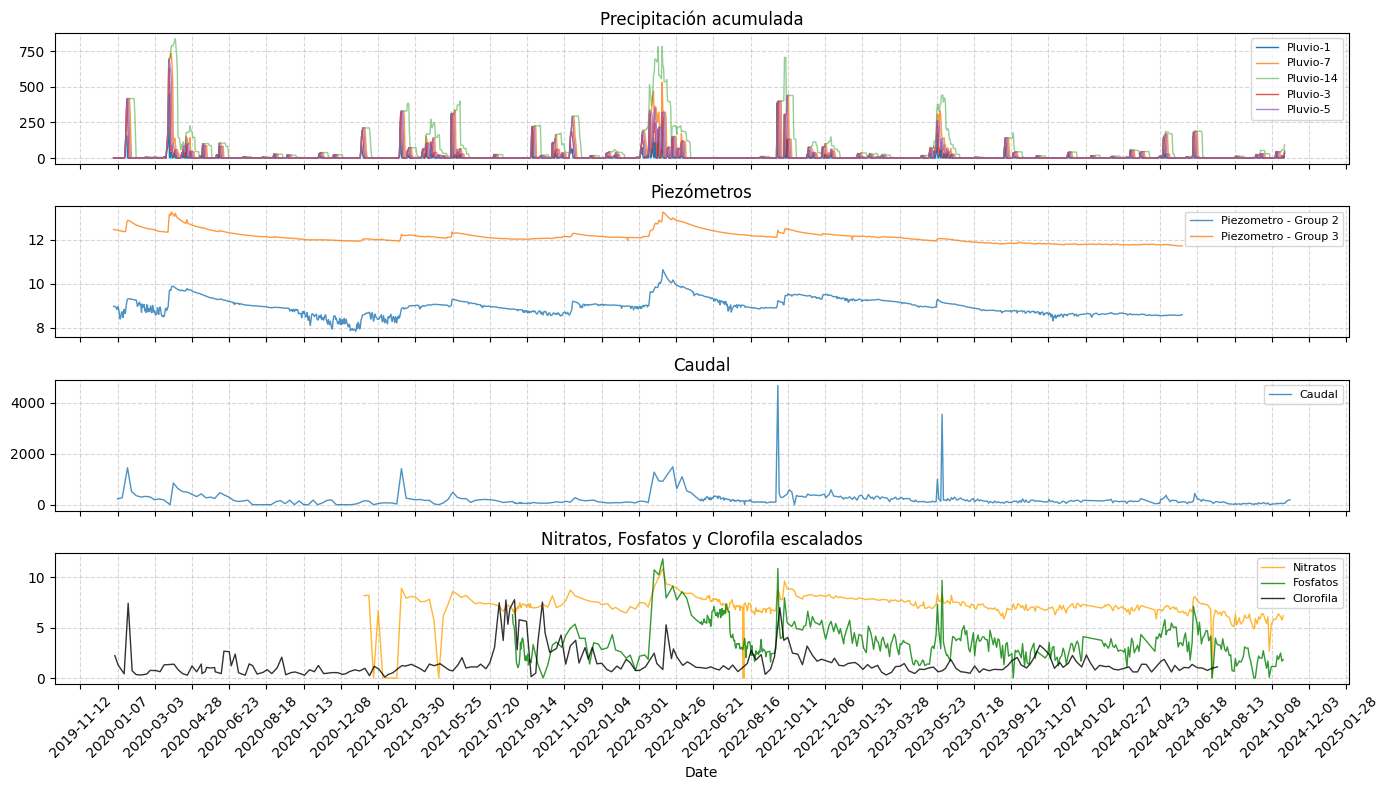

In [106]:
fig, ax = plt.subplots(figsize=(14, 8), nrows=4, ncols=1, sharex=True)

start_date = '2020-01-01'

series1_1 = series1[series1.index >= start_date]
series6 = series6[series6.index >= start_date]
series7 = series7[series7.index >= start_date]
series8 = series8[series8.index >= start_date]
series9 = series9[series9.index >= start_date]

series10 = series10[series10.index >= start_date]
series11 = series11[series11.index >= start_date]

pluvio_scaled = pluvio_scaled[pluvio_scaled.index >= start_date]
nitratos_scaled = nitratos_scaled[nitratos_scaled.index >= start_date]
fosfatos_scaled = fosfatos_scaled[fosfatos_scaled.index >= start_date]
caudal_scaled = caudal_scaled[caudal_scaled.index >= start_date]
clorofila_scaled = clorofila_scaled[clorofila_scaled.index >= start_date]

#ax[0].plot(pluvio_scaled.index, pluvio_scaled, label=f'Pluvio', linewidth=1, alpha = 0.8)
i = 0
ax[i].plot(series1_1.index, series1_1, label=f'Pluvio-1', linewidth=1, alpha = 1)
ax[i].plot(series6.index, series6, label=f'Pluvio-7', linewidth=1, alpha = 0.8)
ax[i].plot(series7.index, series7, label=f'Pluvio-14', linewidth=1, alpha = 0.5)
ax[i].plot(series8.index, series8, label=f'Pluvio-3', linewidth=1, alpha = 0.8)
ax[i].plot(series9.index, series9, label=f'Pluvio-5', linewidth=1, alpha = 0.8)
ax[i].set_title("Precipitación acumulada")

i=1
ax[i].plot(series10.index, series10, label=f'Piezometro - Group 2', linewidth=1, alpha = 0.8)
ax[i].plot(series11.index, series11, label=f'Piezometro - Group 3', linewidth=1, alpha = 0.8)
ax[i].set_title("Piezómetros")

i=2
ax[i].plot(caudal_scaled.index, caudal_scaled, label=f'Caudal', linewidth=1, alpha = 0.8)
ax[i].set_title("Caudal")

i=3
ax[i].plot(nitratos_scaled.index, nitratos_scaled, label=f'Nitratos', linewidth=1, alpha = 0.8, color="orange")
ax[i].plot(fosfatos_scaled.index, fosfatos_scaled, label=f'Fosfatos', linewidth=1, alpha = 0.8, color="green")
ax[i].plot(clorofila_scaled.index, clorofila_scaled, label=f'Clorofila', linewidth=1, alpha = 0.8, color="black")
ax[i].set_title("Nitratos, Fosfatos y Clorofila escalados")

ax[i].set_xlabel('Date')

# ax[1].legend(loc='upper right', fontsize=8)

for i in range (0,4): 
    ax[i].legend(loc='upper right', fontsize=8)
    ax[i].xaxis.set_major_locator(mdates.WeekdayLocator(interval=8))
    ax[i].grid(True, linestyle = '--', alpha = 0.5, which="both")
    ax[i].tick_params(axis='x', rotation=45)


fig.tight_layout()